# **Model Evaluation and Comparison**

This notebook consolidates the recommendation-system models developed across the earlier labs (`6.3.1` through `6.3.5`) and evaluates them on the shared course-rating dataset. Its purpose is to provide one comparison point for memory-based collaborative filtering, matrix-factorization methods, neural-network recommenders, and embedding-based supervised models.

The notebook includes control models because a recommender should improve beyond simple reference predictions. If KNN, NMF, SVD, ANN, or embedding regression are close to the mean or bias controls, the reason may be rating imbalance, sparse user-item history, many cold-start users/items in the test split, weak user/item signal, or hyperparameters that are too restrictive.

The final comparison table and plot should therefore be read as a model-performance diagnostic, not just a leaderboard. The improvement-over-mean table is especially important: it shows whether each model actually beats the correct mean control for its own evaluation family.

## **Notebook Setup**

This section centralizes all package imports, TensorFlow device configuration, and random seed settings used throughout the evaluation. Keeping the setup code together makes the rest of the notebook easier to rerun and audit.

In [364]:
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

from surprise import (
    accuracy,
    BaselineOnly,
    Dataset,
    KNNBasic,
    KNNBaseline,
    NMF,
    NormalPredictor,
    Reader,
    SVD,
)
from surprise.model_selection import GridSearchCV as GS

import keras
from keras import layers
from sklearn.calibration import CalibratedClassifierCV
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import ElasticNet, Lasso, LogisticRegression, Ridge
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    mean_squared_error,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.svm import LinearSVC

from xgboost import XGBClassifier

import tensorflow as tf

# Disable GPU for reproducible CPU execution in this notebook.
tf.config.set_visible_devices([], "GPU")

# Shared random seed for data splits, random controls, and TensorFlow.
rs = 42
np.random.seed(rs)
tf.random.set_seed(rs)

## **Dataset Loading**

This section loads the course-rating data and checks the basic rating distribution. The same ratings are reused by the Surprise collaborative-filtering models, the ANN recommender, and the embedding-based regression/classification models so the comparison remains focused on modeling choices rather than different source data.

In [365]:
##rating_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMSkillsNetwork-ML0321EN-Coursera/labs/v2/module_3/ratings.csv"
rating_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML321EN-SkillsNetwork/labs/datasets/ratings.csv"

rating_df = pd.read_csv(rating_url)

In [366]:
rating_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 233306 entries, 0 to 233305
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   user    233306 non-null  int64  
 1   item    233306 non-null  object 
 2   rating  233306 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 5.3+ MB


In [367]:
rating_df.describe()

,user,rating
count,2.333060e+05,233306.000000
mean,1.099162e+06,2.952954
std,4.771661e+05,0.211737
min,2.000000e+00,2.000000
25%,7.210400e+05,3.000000
50%,1.080061e+06,3.000000
75%,1.466616e+06,3.000000
max,2.103039e+06,3.000000


## **Rating Distribution Check**

Before interpreting RMSE, this section checks how concentrated the ratings are. A balanced rating distribution removes one common reason mean controls look strong, but it does not guarantee that collaborative-filtering models will improve. Sparse user histories or weak user/item preference patterns can still make the mean control difficult to beat.

In [368]:
rating_distribution_df = (
    rating_df["rating"]
    .value_counts(normalize=True)
    .sort_index()
    .rename("proportion")
    .reset_index()
    .rename(columns={"index": "rating"})
)

print(rating_distribution_df)
print(
    f"Most common rating proportion: {rating_distribution_df['proportion'].max():.2%}"
)

   rating  proportion
0     2.0    0.047046
1     3.0    0.952954
Most common rating proportion: 95.30%


## **Surprise Data Split**

This section creates the reproducible train/test split used by the Surprise models and converts the training data into the formats required by the Surprise library.

```text
rating_df[["user", "item", "rating"]]
  -> train_test_split(...): creates surprise_train_df and surprise_test_df
  -> Reader: stores Surprise metadata such as the rating scale
  -> train_dataset: Surprise Dataset built from surprise_train_df for GridSearchCV
  -> trainset: Surprise Trainset built from all training rows for model fitting
  -> testset: held-out list of (user, item, rating) tuples for final evaluation
```

`Reader` does not convert the pandas DataFrame by itself. It only tells Surprise how to interpret the ratings. The actual conversion happens in `Dataset.load_from_df(surprise_train_df, reader=reader)`, which wraps the training split as a Surprise `Dataset`. `build_full_trainset()` then creates the object used by the control models and by the final selected KNN, NMF, and SVD models. The held-out `surprise_test_df` is converted to `testset` only for final `.test(...)` evaluation.

In [369]:
# Reader only stores metadata for Surprise, such as the valid rating scale.
reader = Reader(
    rating_scale=(rating_df["rating"].min(), rating_df["rating"].max())
)

# Split the pandas rating table first so the final test rows stay unseen.
rating_cols = ["user", "item", "rating"]
surprise_train_df, surprise_test_df = train_test_split(
    rating_df[rating_cols],
    test_size=0.3,
    random_state=rs,
    stratify=rating_df["rating"],
)

# Convert only the training split into Surprise objects.
train_dataset = Dataset.load_from_df(surprise_train_df, reader=reader)
trainset = train_dataset.build_full_trainset()

# Surprise .test(...) expects a list of (user, item, rating) tuples.
testset = surprise_test_df.to_records(index=False).tolist()

print(f"Surprise train rows: {len(surprise_train_df):,}")
print(f"Surprise test rows: {len(surprise_test_df):,}")

Surprise train rows: 163,314
Surprise test rows: 69,992


If many users have very few ratings, user-based KNN and matrix factorization have little personal history to learn from. If matrix density is low, item-neighbor and latent-factor estimates can also be noisy. In those cases, the global mean or a simple bias model may be competitive even when the rating classes are balanced.

## **Surprise Control Model Evaluation**

This subsection evaluates the reference models on the held-out Surprise `testset` created above.
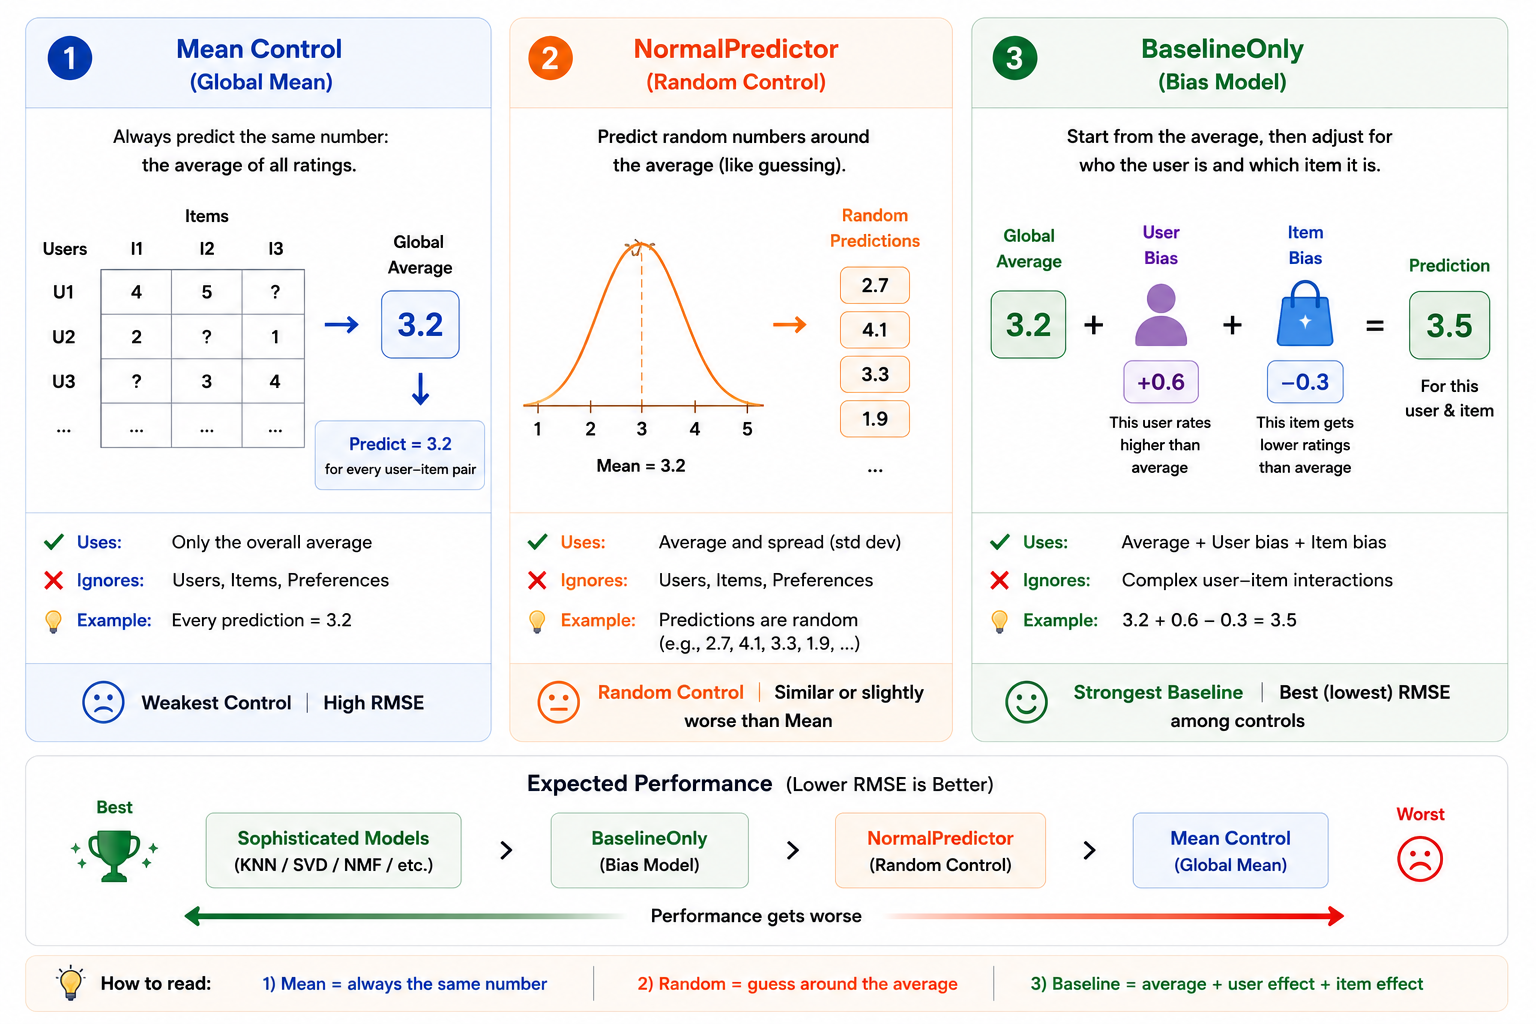
- The mean control predicts the training-set global mean for every test example.

- `NormalPredictor` is a random control that samples ratings from a normal distribution estimated from the training ratings.

- `BaselineOnly` estimates global, user, and item bias terms, so it is a simple bias-based collaborative-filtering model rather than a naive baseline.

These controls provide the comparison point for interpreting whether KNN, NMF, and SVD improve beyond simple average, random, and bias-based predictions.

In [370]:
# Mean control: predict the training-set average rating for every test example.
actual_ratings = []
mean_predictions = []

for user, item, rating in testset:
    actual_ratings.append(rating)
    mean_predictions.append(trainset.global_mean)

# Calculate RMSE (NumPy automatically broadcasts trainset.global_mean)
surprise_mean_rmse = np.sqrt(
    mean_squared_error(actual_ratings, mean_predictions)
)

print(f"Global Mean Control RMSE: {surprise_mean_rmse:.4f}")

Global Mean Control RMSE: 0.2117


In [371]:
# Random control: NormalPredictor samples predictions from a normal
# distribution estimated from the training ratings.
np.random.seed(rs)
algo_random = NormalPredictor()
algo_random.fit(trainset)

# Generate predictions for the test set and calculate RMSE.
random_predictions = algo_random.test(testset)
random_rmse = accuracy.rmse(random_predictions)
print(f"NormalPredictor Random Control RMSE: {random_rmse:.4f}")

RMSE: 0.2612
NormalPredictor Random Control RMSE: 0.2612


In [372]:
# Bias model: BaselineOnly learns global, user, and item bias terms.
# It is stronger than a naive baseline and should be interpreted as a simple model.
bsl_options = {"method": "als", "n_epochs": 5, "reg_u": 12, "reg_i": 5}
algo_bias = BaselineOnly(bsl_options=bsl_options)

algo_bias.fit(trainset)
bias_predictions = algo_bias.test(testset)

bias_model_rmse = accuracy.rmse(bias_predictions)
print(f"Bias Model (Global + User/Item Biases) RMSE: {bias_model_rmse:.4f}")

Estimating biases using als...
RMSE: 0.1581
Bias Model (Global + User/Item Biases) RMSE: 0.1581


## **KNN**

This section evaluates memory-based collaborative filtering with Surprise KNN.

`KNNBasic` calculates user similarities purely based on raw ratings, so it can be distorted by skewed distributions (e.g., if a user rates everything a $5$).

`KNNBaseline` first estimates the global mean, user biases, and item biases, then computes similarities using the residual ratings after these effects are removed. This helps reduce the influence of systematic rating biases and allows similarities to focus more on true preference patterns.

 The grid search compares neighborhood sizes, similarity metrics, and user-based versus item-based neighborhoods. The best configuration is then trained and tested to estimate how well nearest-neighbor rating patterns generalize.

In [373]:
# =========================
# 1. Define parameter grid
# =========================
knn_param_grid = {
    "k": [10, 20, 40],
    "min_k": [1, 3],
    "sim_options": {
        "name": ["msd", "cosine", "pearson_baseline"],
        "user_based": [False, True],
    },
}

# =========================
# 2. Run Grid Search
# =========================
knn_gs = GS(
    KNNBasic,
    knn_param_grid,
    measures=["rmse"],
    cv=3,
    n_jobs=4,
)

knn_gs.fit(train_dataset)

Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Computing the msd similarity matrix...
Computing the msd similarity matrix...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Done computing similarity matrix.
Done computing similarity matrix.
Computing the cosine similarity matrix...
Computing the cosine similarity matrix...
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done com

In [374]:
# =========================
# 3. Convert results to DataFrame
# =========================
# Convert GridSearchCV results to DataFrame
knn_results_df = pd.DataFrame(knn_gs.cv_results)

# Extract parameters + rename + format in one pipeline
knn_results_df = (
    knn_results_df.assign(
        similarity=knn_results_df["param_sim_options"].str["name"],
        user_based=knn_results_df["param_sim_options"].str["user_based"],
    )
    .rename(columns={"param_k": "k", "mean_test_rmse": "val_rmse"})[
        ["k", "similarity", "user_based", "val_rmse"]
    ]
    .sort_values("val_rmse")
)

# Round for presentation
knn_results_df["val_rmse"] = knn_results_df["val_rmse"].round(4)

print(knn_results_df)

     k        similarity  user_based  val_rmse
1   10               msd        True    0.1961
0   10               msd       False    0.1967
7   10               msd        True    0.1968
24  40               msd       False    0.1968
12  20               msd       False    0.1968
13  20               msd        True    0.1972
26  40            cosine       False    0.1973
14  20            cosine       False    0.1973
2   10            cosine       False    0.1973
16  20  pearson_baseline       False    0.1977
28  40  pearson_baseline       False    0.1977
4   10  pearson_baseline       False    0.1977
19  20               msd        True    0.1979
25  40               msd        True    0.1988
31  40               msd        True    0.1995
27  40            cosine        True    0.2033
15  20            cosine        True    0.2039
33  40            cosine        True    0.2040
21  20            cosine        True    0.2045
6   10               msd       False    0.2049
30  40       

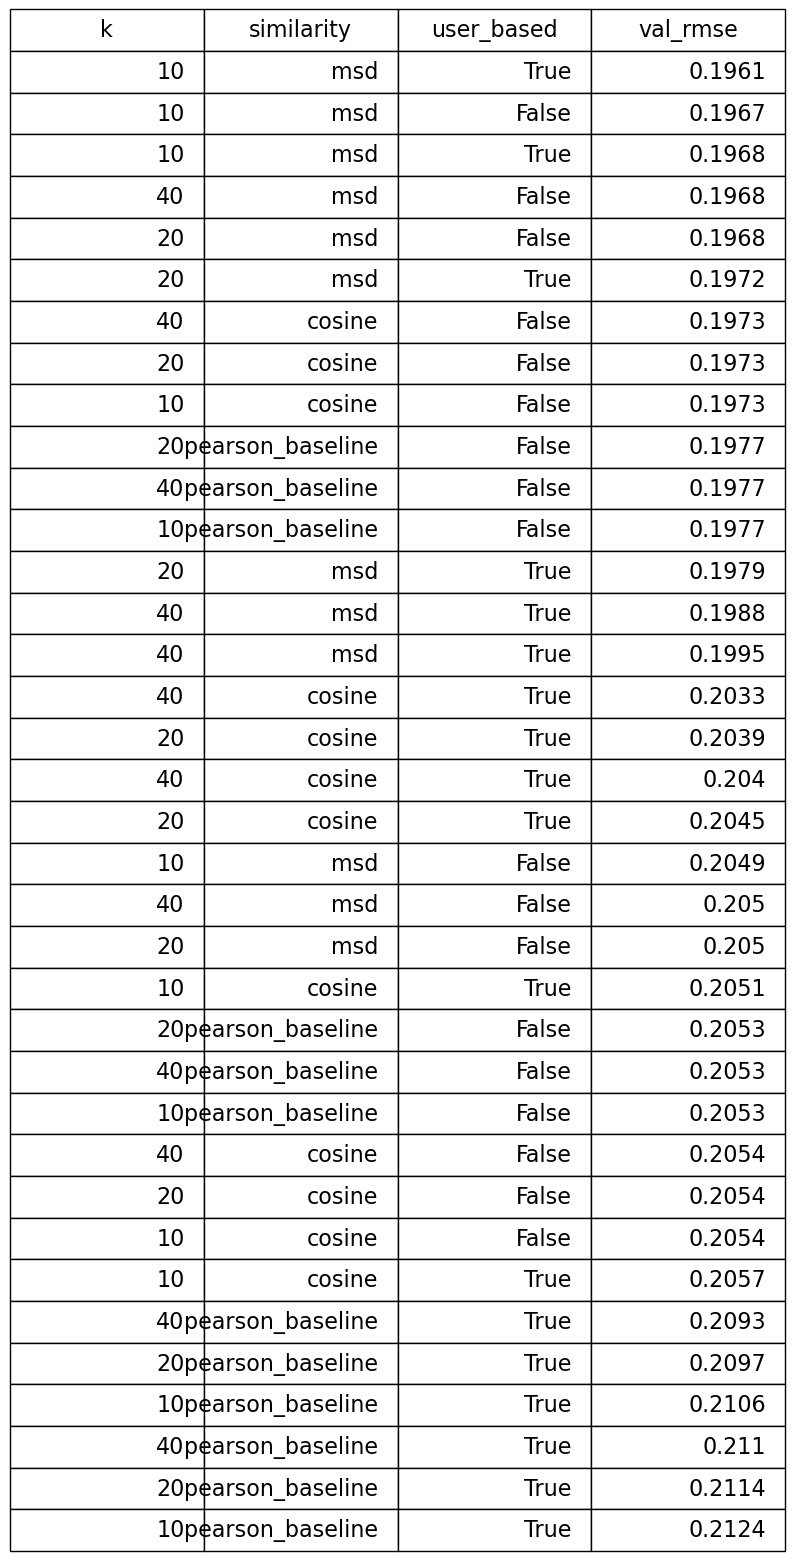

In [375]:
fig, ax = plt.subplots(figsize=(10, 6))  # bigger canvas
ax.axis("off")

table = ax.table(
    cellText=knn_results_df.values,
    colLabels=knn_results_df.columns,
    loc="center",
)

table.auto_set_font_size(False)
table.set_fontsize(16)
table.scale(1, 2.5)  # increase row height
# auto-fit column width
# table.auto_set_column_width(col=list(range(len(df.columns))))
plt.show()

In [376]:
# =========================
# 4. Test the best model
# =========================
# Train best model
knn_best_model = KNNBaseline(**knn_gs.best_params["rmse"])
knn_best_model.fit(trainset)

# Evaluate
knn_predictions = knn_best_model.test(testset)
knn_test_rmse = accuracy.rmse(knn_predictions)

Estimating biases using als...
Computing the msd similarity matrix...
Done computing similarity matrix.
RMSE: 0.1395


## **NMF**

<!-- codex-doc -->
This section evaluates Surprise non-negative matrix factorization. NMF represents users and items with low-dimensional non-negative latent factors and predicts ratings from their interaction. The grid search explores different factor counts and training epochs before evaluating the best model on the held-out test set.

In [377]:
# =========================
# 1. Define parameter grid
# =========================
nmf_param_grid = {
    "n_factors": [5, 15, 30],
    "n_epochs": [20, 50],
    "biased": [True, False],
}

# =========================
# 2. Run Grid Search
# =========================
nmf_gs = GS(
    NMF,
    nmf_param_grid,
    measures=["rmse"],
    cv=3,
    n_jobs=2,
)

nmf_gs.fit(train_dataset)

# =========================
# 3. Convert results to DataFrame
# =========================
nmf_results_df = (
    pd.DataFrame(nmf_gs.cv_results)
    .rename(
        columns={
            "param_n_factors": "n_factors",
            "param_n_epochs": "n_epochs",
            "param_biased": "biased",
            "mean_test_rmse": "val_rmse",
        }
    )[["n_factors", "n_epochs", "biased", "val_rmse"]]
    .sort_values("val_rmse")
)

nmf_results_df["val_rmse"] = nmf_results_df["val_rmse"].round(4)
nmf_results_df

,n_factors,n_epochs,biased,val_rmse
0,5,20,True,0.1632
2,5,50,True,0.1802
11,30,50,False,0.1976
9,30,20,False,0.1992
5,15,20,False,0.2058
7,15,50,False,0.2248
6,15,50,True,0.2285
10,30,50,True,0.2722
4,15,20,True,0.2899
8,30,20,True,0.3312


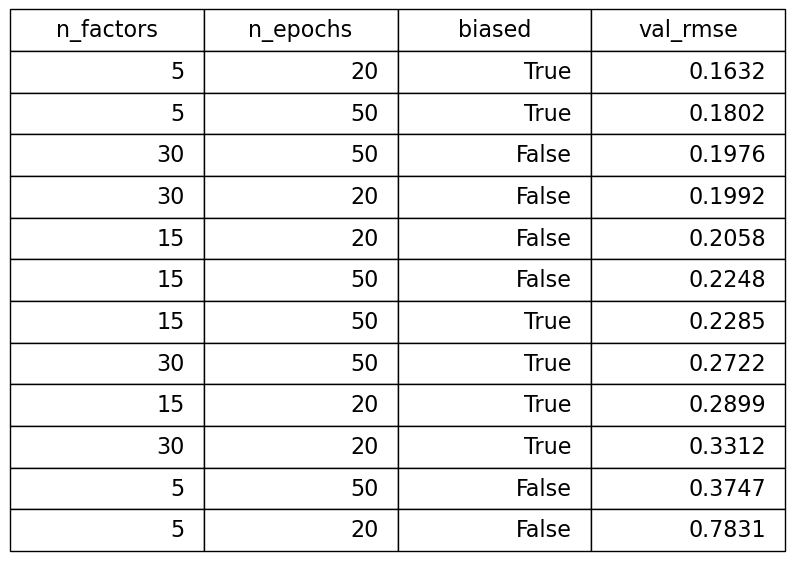

In [378]:
fig, ax = plt.subplots(figsize=(10, 6))  # bigger canvas
ax.axis("off")

table = ax.table(
    cellText=nmf_results_df.values,
    colLabels=nmf_results_df.columns,
    loc="center",
)

table.auto_set_font_size(False)
table.set_fontsize(16)
table.scale(1, 2.5)  # increase row height
# auto-fit column width
# table.auto_set_column_width(col=list(range(len(df.columns))))
plt.show()

In [379]:
# =========================
# 4. Test the best model
# =========================
# Train best model
nmf_best_model = NMF(**nmf_gs.best_params["rmse"])
nmf_best_model.fit(trainset)

# Evaluate
nmf_predictions = nmf_best_model.test(testset)
nmf_test_rmse = accuracy.rmse(nmf_predictions)

RMSE: 0.2055


## **SVD**

<!-- codex-doc -->
This section evaluates Surprise SVD matrix factorization. SVD learns user and item latent factors with regularization and gradient-based optimization. The grid search tests factor size, epoch count, learning rate, and regularization to determine whether latent-factor modeling improves over the control and bias models.

In [380]:
# =========================
# 1. Define parameter grid
# =========================
svd_param_grid = {
    "n_factors": [5, 20, 50],
    "n_epochs": [20, 50],
    "lr_all": [0.002, 0.005],
    "reg_all": [0.02, 0.1, 0.2],
}

# =========================
# 2. Run Grid Search
# =========================
svd_gs = GS(
    SVD,
    svd_param_grid,
    measures=["rmse"],
    cv=3,
    n_jobs=2,
)

svd_gs.fit(train_dataset)

# =========================
# 3. Convert results to DataFrame
# =========================
svd_results_df = (
    pd.DataFrame(svd_gs.cv_results)
    .rename(
        columns={
            "param_n_factors": "n_factors",
            "param_n_epochs": "n_epochs",
            "param_lr_all": "learning_rate",
            "param_reg_all": "regularization",
            "mean_test_rmse": "val_rmse",
        }
    )[["n_factors", "n_epochs", "learning_rate", "regularization", "val_rmse"]]
    .sort_values("val_rmse")
)

svd_results_df["val_rmse"] = svd_results_df["val_rmse"].round(4)
svd_results_df

,n_factors,n_epochs,learning_rate,regularization,val_rmse
8,5,50,0.002,0.20,0.1734
32,50,50,0.002,0.20,0.1734
20,20,50,0.002,0.20,0.1734
7,5,50,0.002,0.10,0.1745
19,20,50,0.002,0.10,0.1745
31,50,50,0.002,0.10,0.1745
6,5,50,0.002,0.02,0.1760
18,20,50,0.002,0.02,0.1762
30,50,50,0.002,0.02,0.1763
2,5,20,0.002,0.20,0.1782


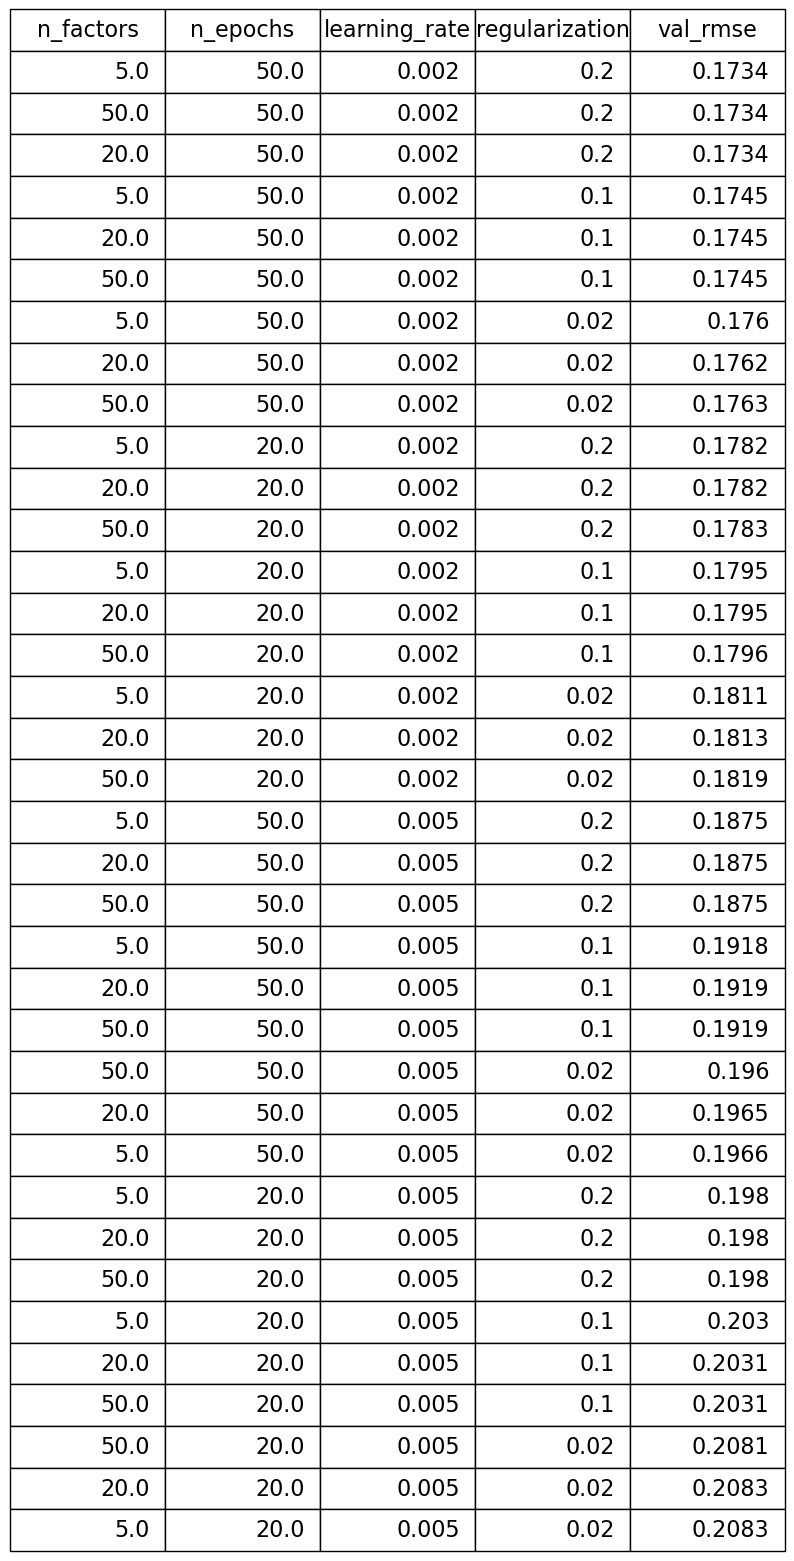

In [381]:
fig, ax = plt.subplots(figsize=(10, 6))  # bigger canvas
ax.axis("off")

table = ax.table(
    cellText=svd_results_df.values,
    colLabels=svd_results_df.columns,
    loc="center",
)

table.auto_set_font_size(False)
table.set_fontsize(16)
table.scale(1, 2.5)  # increase row height
# auto-fit column width
# table.auto_set_column_width(col=list(range(len(df.columns))))
plt.show()

In [382]:
# =========================
# 4. Test the best model
# =========================
# Train best model
svd_best_model = SVD(**svd_gs.best_params["rmse"])
svd_best_model.fit(trainset)

# Evaluate
svd_predictions = svd_best_model.test(testset)
svd_test_rmse = accuracy.rmse(svd_predictions)

RMSE: 0.1986


## **ANN**

<!-- codex-doc -->
This section evaluates a neural-network recommender that learns user and item embeddings directly from user-item rating pairs. Ratings are scaled for neural-network training, several embedding and optimization settings are tried, and the best validation model is evaluated on a held-out test split. When comparing with original-scale RMSE models, predictions should be transformed back to the original rating scale.

In [383]:
num_users = len(rating_df["user"].unique())
num_items = len(rating_df["item"].unique())
print(f"There are total `{num_users}` of users and `{num_items}` items")

There are total `33901` of users and `126` items


In [384]:
def process_dataset(raw_data):
    # Make a copy of the original data (not clear why we need this)
    encoded_data = raw_data.copy()

    # Mapping user ids to indices
    user_list = encoded_data["user"].unique().tolist()
    user_id2idx_dict = {x: i for i, x in enumerate(user_list)}
    user_idx2id_dict = {i: x for i, x in enumerate(user_list)}

    # Mapping course ids to indices
    course_list = encoded_data["item"].unique().tolist()
    course_id2idx_dict = {x: i for i, x in enumerate(course_list)}
    course_idx2id_dict = {i: x for i, x in enumerate(course_list)}

    # Convert original user ids to idx
    encoded_data["user"] = encoded_data["user"].map(user_id2idx_dict)
    # Convert original course ids to idx
    encoded_data["item"] = encoded_data["item"].map(course_id2idx_dict)
    # Convert rating to int
    encoded_data["rating"] = encoded_data["rating"].values.astype("int")

    return encoded_data, user_idx2id_dict, course_idx2id_dict

In [385]:
encoded_data, user_idx2id_dict, course_idx2id_dict = process_dataset(rating_df)

In [386]:
def generate_train_test_datasets(dataset, scale=True):

    # Features
    x = dataset[["user", "item"]].values
    y = dataset["rating"].values.reshape(-1, 1)  # make it 2D for scaler

    # Step 1: split train (80%) and temp (20%)
    x_train, x_temp, y_train, y_temp = train_test_split(
        x, y, test_size=0.2, random_state=rs, stratify=y.ravel()
    )

    # Step 2: split temp into val (10%) and test (10%)
    x_val, x_test, y_val, y_test = train_test_split(
        x_temp, y_temp, test_size=0.5, random_state=rs, stratify=y_temp.ravel()
    )

    scaler = None
    # Prevent data leakage: fit scaler ONLY on training data.
    if scale:
        scaler = MinMaxScaler()
        y_train = scaler.fit_transform(y_train)
        y_val = scaler.transform(y_val)
        y_test = scaler.transform(y_test)

    return x_train, x_val, x_test, y_train, y_val, y_test, scaler

In [387]:
x_train, x_val, x_test, y_train, y_val, y_test, rating_scaler = (
    generate_train_test_datasets(encoded_data)
)

In [388]:
# ANN-specific controls use the same ANN train/test split and original rating scale.
ann_y_train_original = rating_scaler.inverse_transform(y_train).ravel()
ann_y_test_original = rating_scaler.inverse_transform(y_test).ravel()

ann_mean_pred = np.full_like(
    ann_y_test_original, ann_y_train_original.mean(), dtype=float
)
ann_mean_control_rmse = np.sqrt(
    mean_squared_error(ann_y_test_original, ann_mean_pred)
)

rng = np.random.default_rng(rs)
ann_random_pred = rng.uniform(
    low=ann_y_train_original.min(),
    high=ann_y_train_original.max(),
    size=len(ann_y_test_original),
)
ann_random_control_rmse = np.sqrt(
    mean_squared_error(ann_y_test_original, ann_random_pred)
)

print(f"ANN Mean Control RMSE: {ann_mean_control_rmse:.4f}")
print(f"ANN Random Control RMSE: {ann_random_control_rmse:.4f}")

ANN Mean Control RMSE: 0.2118
ANN Random Control RMSE: 0.5778


In [389]:
## compile and fit the updated model
## evaluate the updated model


class RecommenderNetV2(keras.Model):
    def __init__(
        self,
        num_users,
        num_items,
        embedding_size=16,
        activation="relu",
        **kwargs
    ):
        """
        Constructor
        :param int num_users: number of users
        :param int num_items: number of items
        :param int embedding_size: the size of embedding vector
        """
        super(RecommenderNetV2, self).__init__(**kwargs)
        self.num_users = num_users  # how many users in dataset
        self.num_items = num_items  # how many items
        self.embedding_size = embedding_size  # length of embedding vector

        # Define a user_embedding vector
        # Input dimension is the num_users
        # Output dimension is the embedding size
        self.user_embedding_layer = layers.Embedding(
            input_dim=num_users,
            output_dim=embedding_size,
            name="user_embedding_layer_v2",
            embeddings_initializer="he_normal",
            embeddings_regularizer=keras.regularizers.l2(1e-6),
        )

        # Define a user bias layer
        self.user_bias = layers.Embedding(
            input_dim=num_users,
            output_dim=1,
            name="user_bias_v2",
        )

        # Define an item_embedding vector
        # Input dimension is the num_items
        # Output dimension is the embedding size
        self.item_embedding_layer = layers.Embedding(
            input_dim=num_items,
            output_dim=embedding_size,
            name="item_embedding_layer_v2",
            embeddings_initializer="he_normal",
            embeddings_regularizer=keras.regularizers.l2(1e-6),
        )

        # Define an item bias layer
        self.item_bias = layers.Embedding(
            input_dim=num_items,
            output_dim=1,
            name="item_bias_v2",
        )
        self.output_layer = layers.Dense(
            1, activation=activation, name="output_layer"
        )

    def call(self, inputs):
        """
        method to be called during model fitting

        :param inputs: user and item one-hot vectors
        """
        # Compute the user embedding vector
        username = self.user_embedding_layer(inputs[:, 0])
        user_bias = self.user_bias(inputs[:, 0])
        course_id = self.item_embedding_layer(inputs[:, 1])
        item_bias = self.item_bias(inputs[:, 1])

        # Sum across rows
        interaction = tf.reduce_sum(username * course_id, axis=1, keepdims=True)
        x = interaction + user_bias + item_bias
        # x = self.hidden1(x)
        # x = self.hidden2(x)
        x = self.output_layer(x)
        return x

In [390]:
def train_model(embedding_size, learning_rate, activation, epochs=10):

    model = RecommenderNetV2(
        num_users,
        num_items,
        embedding_size=embedding_size,
        activation=activation,
    )

    model.compile(
        loss="mse",
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        metrics=[tf.keras.metrics.RootMeanSquaredError()],
    )

    history = model.fit(
        x_train,
        y_train,
        batch_size=32,
        epochs=epochs,
        validation_data=(x_val, y_val),
        verbose=0,
    )

    val_rmse = history.history["val_root_mean_squared_error"][-1]

    return val_rmse, model, history

In [391]:
# Grid search
ann_best_rmse = float("inf")
ann_best_params = None
ann_best_model = None

ann_results = []

for lr in [0.001, 0.01]:
    for emb in [16, 32]:
        for act in ["relu", "tanh"]:

            val_rmse, model, history = train_model(emb, lr, act)

            print(
                f"lr={lr}, emb={emb}, act={act} | " f"val_rmse={val_rmse:.4f}"
            )

            ann_results.append(
                {
                    "lr": lr,
                    "emb": emb,
                    "act": act,
                    "val_rmse": val_rmse,
                }
            )

            if val_rmse < ann_best_rmse:
                ann_best_rmse = val_rmse
                ann_best_params = (emb, lr, act)
                ann_best_model = model

print("Best params:", ann_best_params)
print("Best validation RMSE:", ann_best_rmse)

lr=0.001, emb=16, act=relu | val_rmse=0.1158
lr=0.001, emb=16, act=tanh | val_rmse=0.0861
lr=0.001, emb=32, act=relu | val_rmse=0.1183
lr=0.001, emb=32, act=tanh | val_rmse=0.0880
lr=0.01, emb=16, act=relu | val_rmse=0.1216
lr=0.01, emb=16, act=tanh | val_rmse=0.0858
lr=0.01, emb=32, act=relu | val_rmse=0.1211
lr=0.01, emb=32, act=tanh | val_rmse=0.0878
Best params: (16, 0.01, 'tanh')
Best validation RMSE: 0.08580456674098969


In [392]:
ann_best_model

<RecommenderNetV2 name=recommender_net_v2_46, built=True>

In [393]:
ann_results_df = pd.DataFrame(ann_results).sort_values("val_rmse")
ann_results_df["val_rmse"] = ann_results_df["val_rmse"].round(4)

print(ann_results_df)

      lr  emb   act  val_rmse
5  0.010   16  tanh    0.0858
1  0.001   16  tanh    0.0861
7  0.010   32  tanh    0.0878
3  0.001   32  tanh    0.0880
0  0.001   16  relu    0.1158
2  0.001   32  relu    0.1183
6  0.010   32  relu    0.1211
4  0.010   16  relu    0.1216


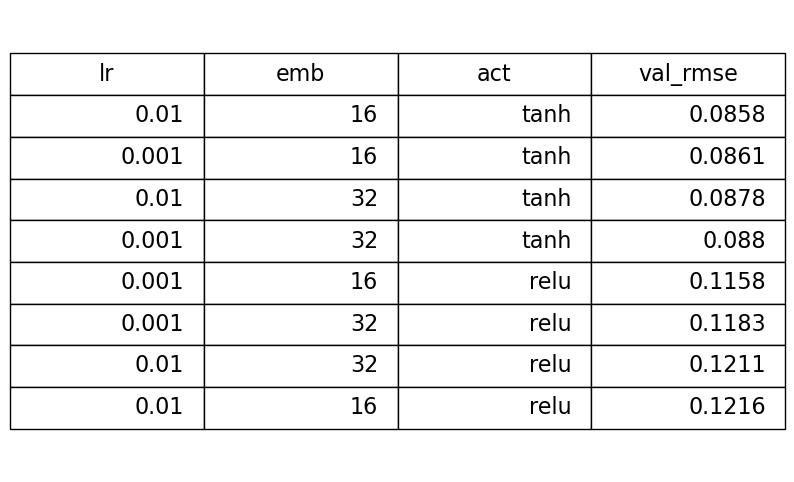

In [394]:
fig, ax = plt.subplots(figsize=(10, 6))  # bigger canvas
ax.axis("off")

table = ax.table(
    cellText=ann_results_df.values,
    colLabels=ann_results_df.columns,
    loc="center",
)

table.auto_set_font_size(False)
table.set_fontsize(16)
table.scale(1, 2.5)  # increase row height
# auto-fit column width
# table.auto_set_column_width(col=list(range(len(ann_results_df.columns))))
plt.show()

In [395]:
# Evaluate the ANN on both the scaled training target and the original rating scale.
ann_test_loss, ann_test_rmse_scaled = ann_best_model.evaluate(
    x_test, y_test, verbose=0
)
ann_pred_scaled = ann_best_model.predict(x_test, verbose=0)

ann_true = rating_scaler.inverse_transform(y_test)
ann_pred = rating_scaler.inverse_transform(ann_pred_scaled)
ann_test_rmse = np.sqrt(mean_squared_error(ann_true, ann_pred))

print("Final test RMSE (scaled target):", round(ann_test_rmse_scaled, 4))
print("Final test RMSE (original rating scale):", round(ann_test_rmse, 4))

Final test RMSE (scaled target): 0.0862
Final test RMSE (original rating scale): 0.0862


## **Regression with Embeddings**

<!-- codex-doc -->
This section evaluates supervised regression models built from the user and course embeddings learned by the ANN model above. Instead of loading old precomputed embedding files, the notebook extracts the embedding matrices directly from `ann_best_model`, maps them back to the current `user` and `item` ids, and merges them with the current `rating_df`.

This matters when you change datasets. Remote embedding files may contain ids from a different dataset, which creates low match rates and many zero-filled features. The generated embeddings below come from the current ANN training data, so the user and item match rates should be 100% for rows seen by the ANN preprocessing step.

The feature table keeps user embeddings, course embeddings, and their element-wise interaction terms. Keeping these pieces separate preserves more information than simply adding the user and course vectors together.

In [396]:
# Extract fresh embeddings from the ANN trained in this notebook.
# These replace the old remote embedding CSV files, which may not match the current dataset.
if "ann_best_model" not in globals():
    raise RuntimeError(
        "Run the ANN training section before extracting embeddings."
    )

user_embedding_matrix = ann_best_model.get_layer(
    "user_embedding_layer_v2"
).get_weights()[0]
item_embedding_matrix = ann_best_model.get_layer(
    "item_embedding_layer_v2"
).get_weights()[0]

embedding_size = user_embedding_matrix.shape[1]
u_features = [f"UFeature{i}" for i in range(embedding_size)]
c_features = [f"CFeature{i}" for i in range(embedding_size)]

user_emb = pd.DataFrame(user_embedding_matrix, columns=u_features)
user_emb.insert(
    0, "user", [user_idx2id_dict[i] for i in range(len(user_embedding_matrix))]
)

item_emb = pd.DataFrame(item_embedding_matrix, columns=c_features)
item_emb.insert(
    0,
    "item",
    [course_idx2id_dict[i] for i in range(len(item_embedding_matrix))],
)

print(f"Generated user embeddings: {user_emb.shape}")
print(f"Generated item embeddings: {item_emb.shape}")

Generated user embeddings: (33901, 17)
Generated item embeddings: (126, 17)


In [397]:
# Check whether the generated embedding tables match the current ratings dataset.
user_embedding_match_rate = rating_df["user"].isin(user_emb["user"]).mean()
item_embedding_match_rate = rating_df["item"].isin(item_emb["item"]).mean()
print(f"User embedding match rate: {user_embedding_match_rate:.2%}")
print(f"Item embedding match rate: {item_embedding_match_rate:.2%}")

if user_embedding_match_rate < 1 or item_embedding_match_rate < 1:
    print(
        "Warning: some rating rows do not have ANN embeddings. "
        "This usually means the embedding section was run with a different dataset "
        "or the ANN preprocessing step did not include every current user/item."
    )

# Merge the generated user and item embeddings into each rating row.
user_emb_merged = pd.merge(
    rating_df,
    user_emb,
    how="left",
    on="user",
)

merged_df = pd.merge(
    user_emb_merged,
    item_emb,
    how="left",
    on="item",
)

# Keep the pipelines runnable if a mismatch appears, but the expected value is now 0.
missing_embedding_values = merged_df[u_features + c_features].isna().sum().sum()
print(f"Missing embedding values after merge: {missing_embedding_values:,}")
merged_df = merged_df.fillna(0)

User embedding match rate: 100.00%
Item embedding match rate: 100.00%
Missing embedding values after merge: 0


In [398]:
# =========================
# 1. Feature Extraction
# =========================
# Keep user and course vectors separate, then add their element-wise interaction.
# This preserves more information than adding the two vectors into one vector.
user_embeddings = merged_df[u_features].reset_index(drop=True)
course_embeddings = merged_df[c_features].reset_index(drop=True)

user_embeddings.columns = [f"UserFeature{i}" for i in range(embedding_size)]
course_embeddings.columns = [f"CourseFeature{i}" for i in range(embedding_size)]

interaction_embeddings = pd.DataFrame(
    user_embeddings.to_numpy() * course_embeddings.to_numpy(),
    columns=[f"InteractionFeature{i}" for i in range(embedding_size)],
)

embedding_dataset = pd.concat(
    [user_embeddings, course_embeddings, interaction_embeddings],
    axis=1,
)
embedding_dataset["rating"] = merged_df["rating"].reset_index(drop=True)

print(f"Embedding feature shape: {embedding_dataset.shape}")
embedding_dataset.head()

Embedding feature shape: (233306, 49)


,UserFeature0,UserFeature1,UserFeature2,UserFeature3,UserFeature4,UserFeature5,UserFeature6,UserFeature7,UserFeature8,UserFeature9,...,InteractionFeature7,InteractionFeature8,InteractionFeature9,InteractionFeature10,InteractionFeature11,InteractionFeature12,InteractionFeature13,InteractionFeature14,InteractionFeature15,rating
0,5.107932e-10,2.736017e-10,-9.379621e-09,-2.031864e-09,2.663014e-10,3.246200e-09,-4.066180e-10,-4.925043e-10,-8.893366e-10,4.304365e-11,...,-4.396421e-12,-2.079211e-12,-1.100584e-12,5.451820e-11,1.566730e-13,-6.307591e-14,-2.134247e-10,4.311955e-15,-2.929484e-14,3.0
1,9.675355e-32,1.953438e-31,3.780583e-31,4.103537e-31,4.698276e-31,-4.272006e-31,-3.524271e-31,3.532684e-31,-3.930626e-31,-4.366013e-32,...,1.994008e-31,1.335120e-31,-2.847827e-33,-7.518931e-32,3.626351e-31,3.603756e-31,-1.154797e-31,-1.841157e-32,6.258126e-32,3.0
2,-5.694007e-10,-3.226975e-11,2.956651e-08,8.296171e-10,-5.550924e-10,-1.126695e-09,-5.583175e-10,-1.003873e-09,-2.657173e-09,1.920482e-09,...,-4.646325e-13,-2.572667e-12,-1.438517e-12,-2.075270e-12,-1.122707e-12,-5.515091e-13,-8.209255e-12,-1.852117e-12,-2.556757e-12,3.0
3,-1.311082e-15,-5.899096e-15,5.098400e-14,-1.888987e-14,-7.482668e-16,1.509003e-14,1.815682e-14,2.362085e-16,-8.757661e-15,8.248127e-16,...,-2.385916e-18,4.846345e-16,-1.874608e-16,3.868155e-16,-4.197722e-15,4.205383e-16,-5.826568e-15,1.830268e-15,-4.235443e-16,3.0
4,1.648938e-31,-3.504168e-31,-3.496270e-31,5.368934e-31,-2.804924e-31,-3.048440e-31,5.868435e-31,-2.208977e-31,2.755263e-31,-1.107986e-31,...,-4.586925e-32,4.191290e-33,2.751682e-32,-2.924359e-32,-1.572699e-31,3.612061e-32,-1.050514e-31,1.124589e-32,2.498194e-32,3.0


In [399]:
X = embedding_dataset.iloc[:, :-1]
y = embedding_dataset.iloc[:, -1]
print(f"Input data shape: {X.shape}, Output data shape: {y.shape}")

(
    X_train_embedding_reg,
    X_test_embedding_reg,
    y_train_embedding_reg,
    y_test_embedding_reg,
) = train_test_split(X, y, test_size=0.3, random_state=rs, stratify=y)

Input data shape: (233306, 48), Output data shape: (233306,)


In [400]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())   
])

lr_param_grid = [
    {
        "model": [Ridge()],
        "model__alpha": [0.1, 1.0, 10.0],
    },
    {
        "model": [Lasso(max_iter=10000)],
        "model__alpha": [0.1, 1.0, 10.0],
    },
    {
        "model": [ElasticNet(max_iter=10000)],
        "model__alpha": [0.1,  10.0],
        "model__l1_ratio": [0.1,  0.9],
    }
]

lr_grid = GridSearchCV(
    estimator=pipe,
    param_grid=lr_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=3,
    verbose=1,
)

lr_grid.fit(X_train_embedding_reg, y_train_embedding_reg)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,estimator,"Pipeline(step...l', Ridge())])"
,param_grid,"[{'model': [Ridge()], 'model__alpha': [0.1, 1.0, ...]}, {'model': [Lasso(max_iter=10000)], 'model__alpha': [0.1, 1.0, ...]}, ...]"
,scoring,'neg_root_mean_squared_error'
,n_jobs,None
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [401]:
# Convert results to DataFrame
df = pd.DataFrame(lr_grid.cv_results_)

# Build clean results table
lr_results_df = (
    df.assign(
        Model=df["param_model"].astype(str),
        alpha=df["param_model__alpha"],
        l1_ratio=df["param_model__l1_ratio"].fillna("-"),
        val_rmse=(-df["mean_test_score"]).round(4),  # neg RMSE → RMSE
    )[["Model", "alpha", "l1_ratio", "val_rmse"]]
    .sort_values("val_rmse")
    .reset_index(drop=True)
)

print(lr_results_df)

                        Model  alpha l1_ratio  val_rmse
0                     Ridge()    0.1        -    0.1791
1                     Ridge()    1.0        -    0.1791
2                     Ridge()   10.0        -    0.1791
3  ElasticNet(max_iter=10000)    0.1      0.1    0.1882
4       Lasso(max_iter=10000)    0.1        -    0.2117
5       Lasso(max_iter=10000)    1.0        -    0.2117
6       Lasso(max_iter=10000)   10.0        -    0.2117
7  ElasticNet(max_iter=10000)    0.1      0.9    0.2117
8  ElasticNet(max_iter=10000)   10.0      0.1    0.2117
9  ElasticNet(max_iter=10000)   10.0      0.9    0.2117


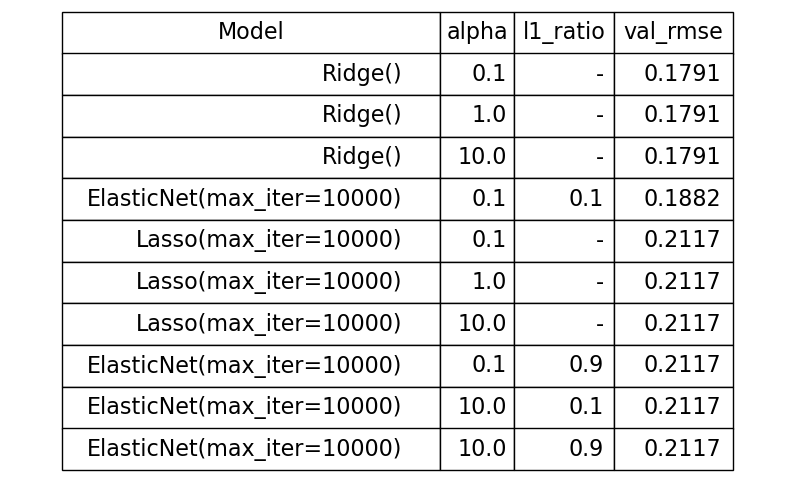

In [402]:
fig, ax = plt.subplots(figsize=(10, 6))  # bigger canvas
ax.axis("off")

table = ax.table(
    cellText=lr_results_df.values, colLabels=lr_results_df.columns, loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(16)
table.scale(1, 2.5)  # increase row height
# auto-fit column width
table.auto_set_column_width(col=list(range(len(lr_results_df.columns))))
plt.show()

In [403]:
# Best model from grid search
lr_best_model = lr_grid.best_estimator_

# Predict
y_pred = lr_best_model.predict(X_test_embedding_reg)

# RMSE
lr_test_rmse = np.sqrt(mean_squared_error(y_test_embedding_reg, y_pred))

print("Final test RMSE:", round(lr_test_rmse, 4))

Final test RMSE: 0.1795


## **Baseline and Random (Sklearn)**

<!-- codex-doc -->
This section adds scikit-learn controls for the embedding-regression task. The mean `DummyRegressor` is the true naive baseline for RMSE in this feature setup, while the uniform random predictor checks how much worse an uninformed rating guess performs. These controls help determine whether embedding regression improves beyond simply predicting the average rating.

In [404]:
# 1. Create the naive baseline (predicts the mean of y_train every time)
dummy_regr = DummyRegressor(strategy="mean")
dummy_regr.fit(X_train_embedding_reg, y_train_embedding_reg)

# 2. Predict on your test set
y_baseline_pred = dummy_regr.predict(X_test_embedding_reg)

# 3. Calculate RMSE
Embedding_Baseline_rmse = np.sqrt(
    mean_squared_error(y_test_embedding_reg, y_baseline_pred)
)

print(f"Global Baseline RMSE: {Embedding_Baseline_rmse:.4f}")

Global Baseline RMSE: 0.2117


In [405]:
# 1. Identify the range of your ratings from the training set
low = y_train_embedding_reg.min()
high = y_train_embedding_reg.max()

# 2. Generate reproducible random predictions within that same range.
rng = np.random.default_rng(rs)
y_random_pred = rng.uniform(low=low, high=high, size=len(y_test_embedding_reg))

# 3. Calculate Random RMSE
Embedding_Random_rmse = np.sqrt(
    mean_squared_error(y_test_embedding_reg, y_random_pred)
)

print(f"Random Baseline RMSE: {Embedding_Random_rmse:.4f}")

Random Baseline RMSE: 0.5769


In [406]:
rmse_rows = [
    ("Surprise", "Mean Control", surprise_mean_rmse),
    ("Surprise", "Random Control", random_rmse),
    ("Surprise", "Bias Model", bias_model_rmse),
    ("Surprise", "KNN", knn_test_rmse),
    ("Surprise", "NMF", nmf_test_rmse),
    ("Surprise", "SVD", svd_test_rmse),
    ("ANN", "Mean Control", ann_mean_control_rmse),
    ("ANN", "Random Control", ann_random_control_rmse),
    ("ANN", "Original Scale", ann_test_rmse),
    ("Embedding Regression", "Mean Control", Embedding_Baseline_rmse),
    ("Embedding Regression", "Random Control", Embedding_Random_rmse),
    ("Embedding Regression", "LR", lr_test_rmse),
]

rmse_df = pd.DataFrame(rmse_rows, columns=["Family", "Model", "Test_RMSE"])
rmse_df["Test_RMSE"] = rmse_df["Test_RMSE"].round(4)
rmse_df

,Family,Model,Test_RMSE
0,Surprise,Mean Control,0.2117
1,Surprise,Random Control,0.2612
2,Surprise,Bias Model,0.1581
3,Surprise,KNN,0.1395
4,Surprise,NMF,0.2055
5,Surprise,SVD,0.1986
6,ANN,Mean Control,0.2118
7,ANN,Random Control,0.5778
8,ANN,Original Scale,0.0862
9,Embedding Regression,Mean Control,0.2117


## **Why Models May Not Beat Controls**

If the improvement table shows KNN, NMF, SVD, ANN, or embedding regression close to their mean controls, that usually means the model has not found predictive user-item structure beyond the average rating. Common reasons include sparse user histories, many users with only one or two ratings, weak item-to-item preference patterns, or models that are too constrained by the current hyperparameter grid.

For Surprise models, `BaselineOnly` is already a meaningful user/item-bias model. If SVD is close to the mean or bias model, the latent factors are not adding much beyond simple average/bias effects. If NMF is worse, its non-negative factorization assumptions or hyperparameters may not fit this data. If KNNBaseline is close to `BaselineOnly`, neighborhood information is not adding much beyond the baseline bias estimates.

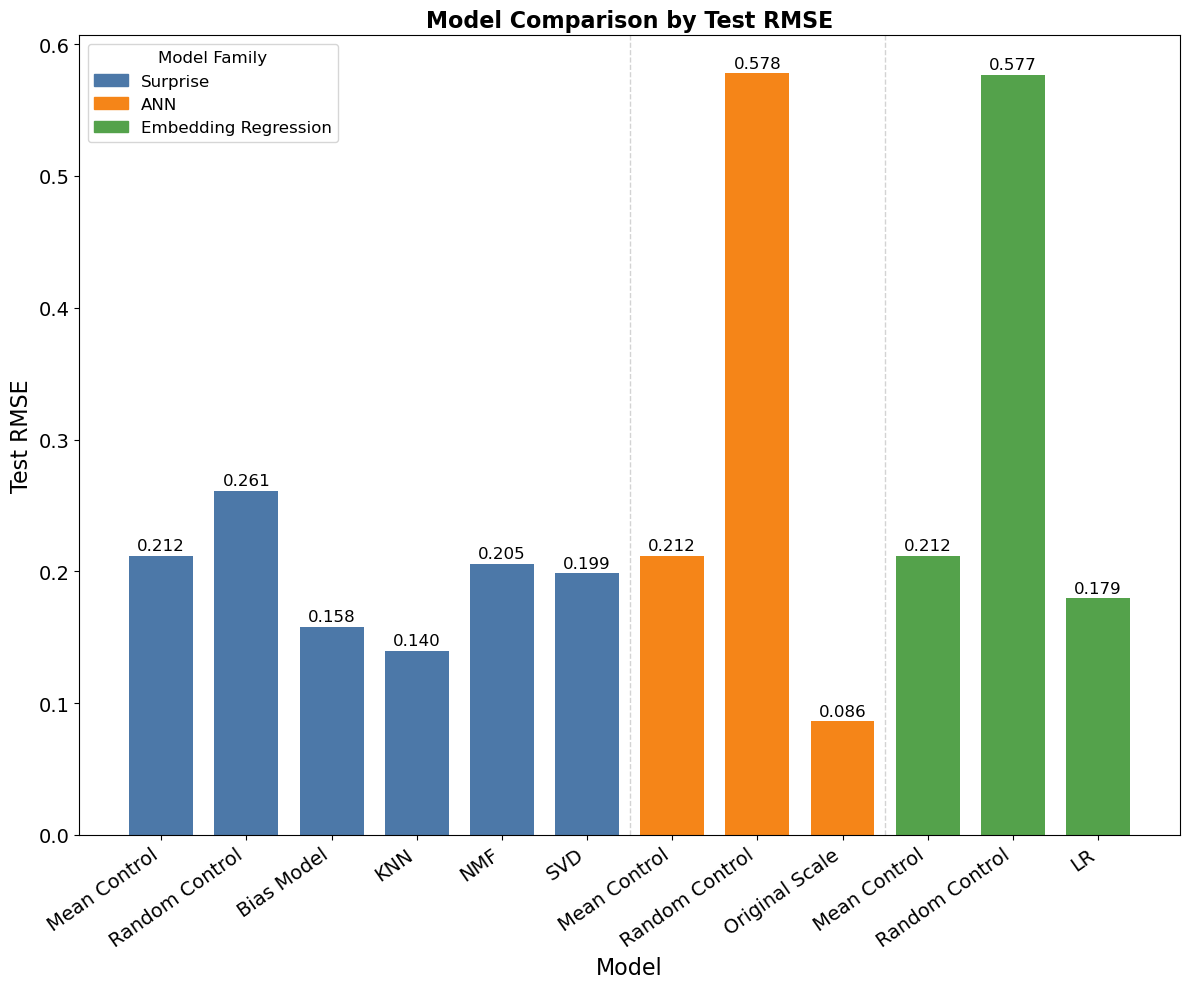

In [407]:
# Plot model RMSE values. Bars are grouped by model family and colored by family.
family_colors = {
    "Surprise": "#4C78A8",
    "ANN": "#F58518",
    "Embedding Regression": "#54A24B",
}
family_order = {
    "Surprise": 0,
    "ANN": 1,
    "Embedding Regression": 2,
}

plot_df = rmse_df.copy().reset_index(drop=True)
plot_df["Family_Order"] = plot_df["Family"].map(family_order)
plot_df["Original_Order"] = plot_df.index
plot_df = plot_df.sort_values(
    ["Family_Order", "Original_Order"],
    kind="stable",
).reset_index(drop=True)

bar_colors = plot_df["Family"].map(family_colors).fillna("#999999")
plot_labels = plot_df["Model"].tolist()
x_positions = np.arange(len(plot_df))

plt.figure(figsize=(12, 10))
bars = plt.bar(x_positions, plot_df["Test_RMSE"], color=bar_colors, width=0.75)

plt.ylabel("Test RMSE", fontsize=16)
plt.xlabel("Model", fontsize=16)
plt.title("Model Comparison by Test RMSE", fontsize=16, fontweight="bold")

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color=color, label=family)
    for family, color in family_colors.items()
    if family in plot_df["Family"].values
]
plt.legend(handles=legend_handles, title="Model Family", fontsize=12, title_fontsize=12)

# Numeric x positions prevent bars with repeated model names from overlapping.
plt.xticks(x_positions, plot_labels, rotation=35, ha="right")

# Add light separators between family groups.
family_change_positions = np.where(plot_df["Family"].ne(plot_df["Family"].shift()).to_numpy())[0]
for pos in family_change_positions[1:]:
    plt.axvline(pos - 0.5, color="lightgray", linestyle="--", linewidth=1)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.002,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=12,
    )

plt.tick_params(labelsize=14)
plt.tight_layout()
plt.show()

## **Classification with Embeddings**

<!-- codex-doc -->
This section reframes the rating task as classification after encoding the observed rating values as classes. It trains several classifiers on the embedding features and reports accuracy, precision, recall, F1, and AUC. These metrics are useful because the dataset is highly imbalanced, and RMSE alone can hide whether models identify the rare lower-rating class.

In [408]:
# =========================
# 2. Target Encoding
# =========================
# Extract features (X) from the interaction_dataset DataFrame
# Selects all rows and all columns except the last column (features)
X = embedding_dataset.iloc[:, :-1]
# Extract the target variable (y_raw) from the embedding_dataset DataFrame
# Selects all rows and only the last column (target variable)
y_raw = embedding_dataset.iloc[:, -1]

# Initialize a LabelEncoder object to encode the target variable
label_encoder = LabelEncoder()
# Encode the target variable (y_raw) using the LabelEncoder
# .values.ravel() converts the target variable to a flattened array before encoding
# The LabelEncoder fits and transforms the target variable, assigning encoded labels to y
y_encode = label_encoder.fit_transform(y_raw.values.ravel())

num_classes = len(label_encoder.classes_)
print(f"Number of classes: {num_classes}")
print(f"Classes: {label_encoder.classes_}")

Number of classes: 2
Classes: [2. 3.]


In [409]:
# =========================
# 3. Train/Test Split
# =========================
(
    X_train_embedding_cla,
    X_test_embedding_cla,
    y_train_embedding_cla,
    y_test_embedding_cla,
) = train_test_split(
    X,
    y_encode,
    test_size=0.2,
    random_state=rs,
    stratify=y_encode,  # train and test sets have the same encoded class distribution
)

In [410]:
# Check class balance in the training split.
class_counts = pd.Series(y_train_embedding_cla).value_counts().sort_index()
class_balance_df = pd.DataFrame(
    {
        "Class": label_encoder.inverse_transform(class_counts.index),
        "Encoded_Class": class_counts.index,
        "Count": class_counts.values,
        "Percent": (class_counts.values / class_counts.values.sum()) * 100,
    }
)

# XGBoost uses scale_pos_weight only for binary classification.
if num_classes == 2:
    negative_count = class_counts.loc[0]
    positive_count = class_counts.loc[1]
    scale_pos_weight = negative_count / positive_count
else:
    scale_pos_weight = None

print(f"XGBoost scale_pos_weight: {scale_pos_weight}")
class_balance_df

XGBoost scale_pos_weight: 0.04936945851582398


,Class,Encoded_Class,Count,Percent
0,2.0,0,8781,4.704678
1,3.0,1,177863,95.295322


In [411]:
# ============
# 4. Models
# ============
# Choose the correct XGBoost objective for the number of rating classes.
# tree_method="exact" avoids an internal histogram-tree error seen in this environment.
xgb_params = {
    "random_state": rs,
    "tree_method": "exact",
    "n_jobs": 1,
    "n_estimators": 100,
    "max_depth": 4,
    "learning_rate": 0.05,
}

if num_classes == 2:
    xgb_params.update(
        {
            "objective": "binary:logistic",
            "eval_metric": "logloss",
            "scale_pos_weight": scale_pos_weight,
        }
    )
else:
    xgb_params.update(
        {
            "objective": "multi:softprob",
            "eval_metric": "mlogloss",
            "num_class": num_classes,
        }
    )

models = {
    "Logistic Regression": Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "model",
                LogisticRegression(class_weight="balanced", max_iter=1000),
            ),
        ]
    ),
    "SVM": Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "model",
                CalibratedClassifierCV(
                    LinearSVC(
                        class_weight="balanced", dual=False, max_iter=2000
                    ),
                    cv=3,
                ),
            ),
        ]
    ),
    "Random Forest": RandomForestClassifier(
        class_weight="balanced", n_estimators=100, random_state=rs
    ),
    "XGBoost": XGBClassifier(**xgb_params),
}

In [412]:
### The main evaluation metrics could be accuracy, recall, precision, F score, and AUC.
cla_results = []

for name, model in models.items():
    print(f"Training {name}...")

    model.fit(X_train_embedding_cla, y_train_embedding_cla)

    # Some models might fail predict_proba in rare cases
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_embedding_cla)
        y_pred = np.argmax(y_prob, axis=1)
    else:
        y_pred = model.predict(X_test_embedding_cla)
        y_prob = None

    # Safe AUC calculation
    auc = np.nan
    try:
        if y_prob is not None:
            # Since your data is binary [0, 1], we take the probability
            # of the POSITIVE class (index 1)
            if y_prob.shape[1] == 2:
                auc = roc_auc_score(y_test_embedding_cla, y_prob[:, 1])
            else:
                # Fallback for multi-class just in case
                auc = roc_auc_score(
                    y_test_embedding_cla,
                    y_prob,
                    multi_class="ovr",
                    average="weighted",
                )
    except Exception as e:
        print(f"AUC failed for {name}: {e}")

    cla_results.append(
        {
            "Model": name,
            "Accuracy": accuracy_score(y_test_embedding_cla, y_pred),
            # weighted = considers imbalance
            "Precision_weighted": precision_score(
                y_test_embedding_cla, y_pred, average="weighted", zero_division=0
            ),
            "Recall_weighted": recall_score(
                y_test_embedding_cla, y_pred, average="weighted", zero_division=0
            ),
            "F1_weighted": f1_score(
                y_test_embedding_cla, y_pred, average="weighted", zero_division=0
            ),
            # macro = treats classes equally (IMPORTANT insight)
            "F1_macro": f1_score(y_test_embedding_cla, y_pred, average="macro", zero_division=0),
            "AUC": auc,
        }
    )

Training Logistic Regression...
Training SVM...
Training Random Forest...
Training XGBoost...


In [413]:
# Convert to DataFrame
cla_results_df = (
    pd.DataFrame(cla_results)
    .round(4)
    .sort_values("F1_weighted", ascending=False)
    .reset_index(drop=True)
)
cla_results_df

,Model,Accuracy,Precision_weighted,Recall_weighted,F1_weighted,F1_macro,AUC
0,Random Forest,0.9677,0.9678,0.9677,0.9598,0.7334,0.8140
1,SVM,0.9647,0.9629,0.9647,0.9556,0.7030,0.8886
2,XGBoost,0.9340,0.9451,0.9340,0.9390,0.6877,0.9258
3,Logistic Regression,0.8768,0.9526,0.8768,0.9054,0.6518,0.8883


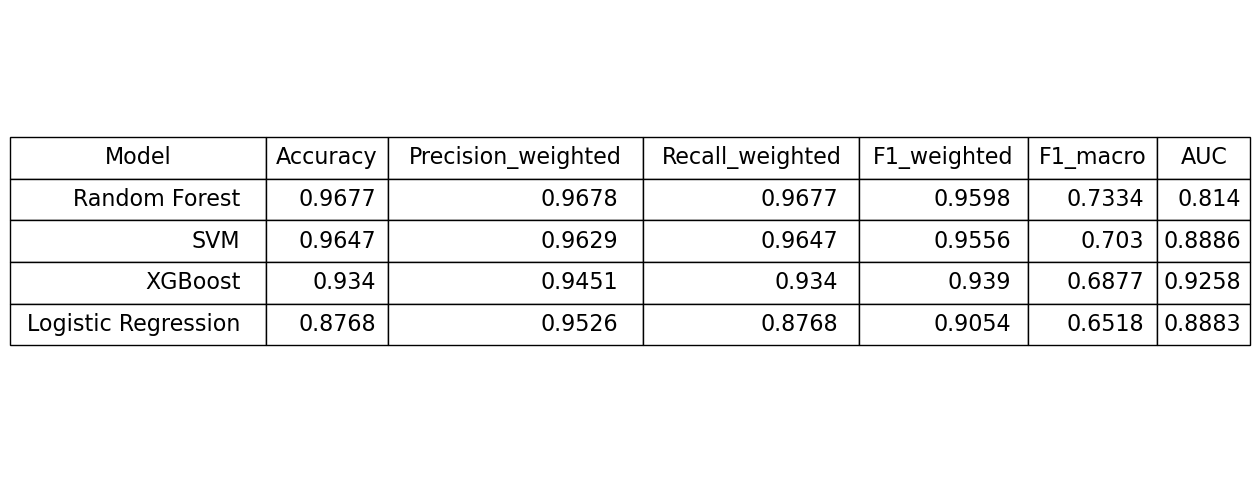

In [414]:
fig, ax = plt.subplots(figsize=(10, 6))  # bigger canvas
ax.axis("off")

table = ax.table(
    cellText=cla_results_df.values,
    colLabels=cla_results_df.columns,
    loc="center",
)

table.auto_set_font_size(False)
table.set_fontsize(16)
table.scale(1, 2.5)  # increase row height
# auto-fit column width
table.auto_set_column_width(col=list(range(len(cla_results_df.columns))))
plt.show()